In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv('data.csv')

In [20]:
df.head(10)

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33
5,70,2,True,True,False,North Program Organization,2.050000e+09,68333.33
6,87,2,True,True,True,Pardis,6.000000e+08,20000.00
7,59,1,True,True,True,Shahran,2.150000e+09,71666.67
8,54,2,True,True,False,Andisheh,4.930000e+08,16433.33
9,71,1,True,True,True,West Ferdows Boulevard,2.370000e+09,79000.00


In [21]:
df['Address'].nunique()

192

In [4]:
df.describe()

,Room,Price,Price(USD)
count,3479.000000,3.479000e+03,3.479000e+03
mean,2.079908,5.359023e+09,1.786341e+05
std,0.758275,8.099935e+09,2.699978e+05
min,0.000000,3.600000e+06,1.200000e+02
25%,2.000000,1.418250e+09,4.727500e+04
50%,2.000000,2.900000e+09,9.666667e+04
75%,2.000000,6.000000e+09,2.000000e+05
max,5.000000,9.240000e+10,3.080000e+06


In [22]:
df['Area'] = pd.to_numeric(df['Area'].str.replace(',', ''))

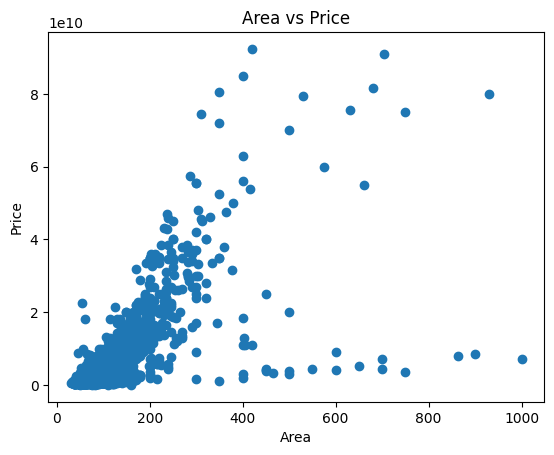

In [24]:
plt.scatter(df['Area'], df['Price'])
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs Price')
plt.show()

In [23]:
df = df[df['Area']<3000]

In [25]:
len(df)

3474

In [26]:
weird = df[(df['Area']>600) & (df['Price']<40000000000)]

In [27]:
weird

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
356,650,2,True,True,False,Absard,5.200000e+09,173333.33
573,863,2,True,True,True,Gheitarieh,7.830000e+09,261000.00
807,1000,2,True,True,False,Damavand,7.000000e+09,233333.33
1974,900,3,True,True,False,Damavand,8.500000e+09,283333.33
2481,700,3,True,True,False,Damavand,4.500000e+09,150000.00
2647,700,3,True,True,False,Damavand,7.000000e+09,233333.33
3115,750,5,True,True,False,Varamin - Beheshti,3.500000e+09,116666.67


In [28]:
df = df.drop(573)

In [29]:
df['Price Per Meter'] = df['Price'] / df['Area']

In [30]:
df.isna().sum()

Area                0
Room                0
Parking             0
Warehouse           0
Elevator            0
Address            23
Price               0
Price(USD)          0
Price Per Meter     0
dtype: int64

In [33]:
len(df)

3450

In [32]:
df['Address'] = df['Address'].str.strip()
df = df.dropna()

In [34]:
df['Address'].nunique()

192

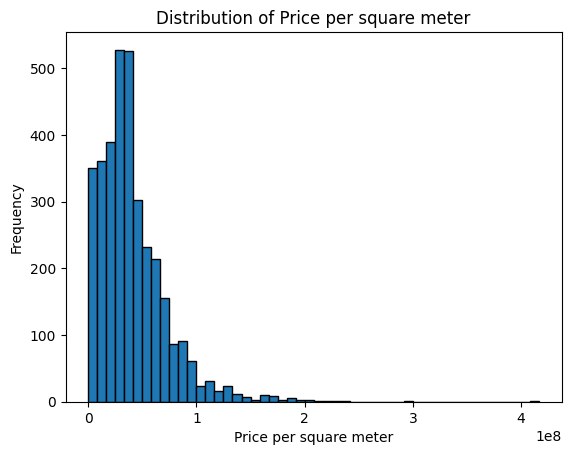

In [36]:
plt.hist(df['Price Per Meter'], bins=50, edgecolor='black')
plt.xlabel('Price per square meter')
plt.ylabel('Frequency')
plt.title('Distribution of Price per square meter')
plt.show()

In [37]:
df['Price Per Meter'].describe()

count    3.450000e+03
mean     4.127364e+07
std      3.165894e+07
min      2.250000e+04
25%      2.000000e+07
50%      3.472953e+07
75%      5.497232e+07
max      4.166667e+08
Name: Price Per Meter, dtype: float64

In [39]:
df.nlargest(10, 'Price Per Meter')

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
3394,54,1,True,True,True,West Ferdows Boulevard,2.250000e+10,750000.00,4.166667e+08
3132,60,1,False,False,False,Shahr-e-Ziba,1.800000e+10,600000.00,3.000000e+08
2394,310,3,True,True,True,Aqdasieh,7.440000e+10,2480000.00,2.400000e+08
1332,350,4,True,True,True,Niavaran,8.050000e+10,2683333.33,2.300000e+08
1707,420,4,True,True,True,Zaferanieh,9.240000e+10,3080000.00,2.200000e+08
430,400,5,True,True,False,Lavasan,8.500000e+10,2833333.33,2.125000e+08
2194,350,4,True,True,True,Niavaran,7.200000e+10,2400000.00,2.057143e+08
1635,287,5,True,True,False,Vanak,5.750000e+10,1916666.67,2.003484e+08
3420,45,1,False,False,True,Si Metri Ji,8.900000e+09,296666.67,1.977778e+08
1565,238,3,True,True,True,Velenjak,4.690000e+10,1563333.33,1.970588e+08


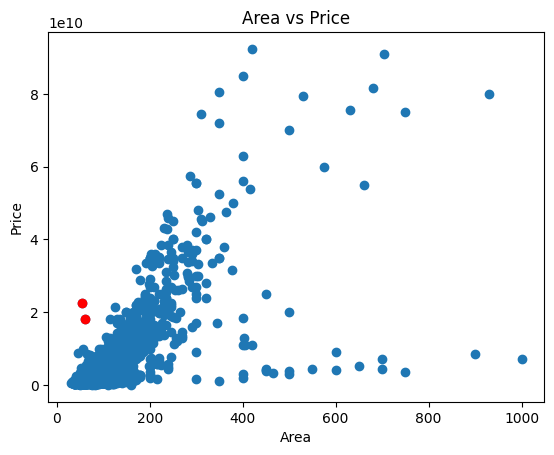

In [40]:
plt.scatter(df['Area'], df['Price'])
row = df.loc[[3132, 3394]]
plt.scatter(row['Area'], row['Price'], color='red')
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs Price')
plt.show()

In [41]:
df = df.drop([3132, 3394])

In [42]:
df.groupby('Address')['Price Per Meter'].mean().sort_values(ascending=False).head(10)

Address
Gandhi        1.400000e+08
Vanak         1.274156e+08
Lavasan       1.172917e+08
Zaferanieh    1.137139e+08
Elahieh       1.122126e+08
Velenjak      1.116799e+08
Kamranieh     1.036243e+08
Niavaran      1.027806e+08
Farmanieh     1.023298e+08
Aqdasieh      9.088586e+07
Name: Price Per Meter, dtype: float64

In [43]:
gandhi = df[df['Address'].str.contains('Gandhi')]

In [44]:
gandhi.describe()

,Area,Room,Price,Price(USD),Price Per Meter
count,1.0,1.0,1.000000e+00,1.00,1.0
mean,500.0,5.0,7.000000e+10,2333333.33,140000000.0
std,NaN,NaN,NaN,NaN,NaN
min,500.0,5.0,7.000000e+10,2333333.33,140000000.0
25%,500.0,5.0,7.000000e+10,2333333.33,140000000.0
50%,500.0,5.0,7.000000e+10,2333333.33,140000000.0
75%,500.0,5.0,7.000000e+10,2333333.33,140000000.0
max,500.0,5.0,7.000000e+10,2333333.33,140000000.0


In [45]:
vanak = df[df['Address'].str.contains('Vanak')]
vanak.describe()

,Area,Room,Price,Price(USD),Price Per Meter
count,2.000000,2.000000,2.000000e+00,2.000000e+00,2.000000e+00
mean,216.000000,4.000000,3.270000e+10,1.090000e+06,1.274156e+08
std,100.409163,1.414214,3.507250e+10,1.169083e+06,1.031426e+08
min,145.000000,3.000000,7.900000e+09,2.633333e+05,5.448276e+07
25%,180.500000,3.500000,2.030000e+10,6.766667e+05,9.094918e+07
50%,216.000000,4.000000,3.270000e+10,1.090000e+06,1.274156e+08
75%,251.500000,4.500000,4.510000e+10,1.503333e+06,1.638820e+08
max,287.000000,5.000000,5.750000e+10,1.916667e+06,2.003484e+08


In [117]:
counts = df['Address'].value_counts()
rare = counts[counts < 10]
with pd.option_context('display.max_rows', None):
    display(rare)

Address
Gisha                      9
Kook                       9
Dezashib                   9
Ray                        9
Fallah                     9
Dehkade Olampic            9
Araj                       9
East Pars                  8
Tehransar                  8
Parastar                   8
Mehran                     8
Shams Abad                 8
Baghestan                  8
Valiasr                    7
Tajrish                    7
Razi                       7
Ekbatan                    7
Hor Square                 6
Tarasht                    6
Sadeghieh                  6
Afsarieh                   6
Absard                     6
Ajudaniye                  5
Hakimiyeh                  5
Shahedshahr                5
Shahrake Quds              5
Azadshahr                  5
ShahrAra                   5
Qarchak                    5
Southern Chitgar           5
Mahallati                  4
Republic                   4
Eskandari                  4
Heshmatieh                 4
Amir B

In [46]:
elahieh = df[df['Address'] == 'Elahieh']
elahieh.describe()

,Area,Room,Price,Price(USD),Price Per Meter
count,17.000000,17.000000,1.700000e+01,1.700000e+01,1.700000e+01
mean,217.235294,2.941176,2.678635e+10,8.928784e+05,1.122126e+08
std,102.835141,0.899346,1.762597e+10,5.875322e+05,4.385208e+07
min,41.000000,1.000000,8.150000e+08,2.716667e+04,1.987805e+07
25%,150.000000,3.000000,1.150000e+10,3.833333e+05,7.823129e+07
50%,204.000000,3.000000,3.166800e+10,1.055600e+06,1.145833e+08
75%,250.000000,3.000000,3.850000e+10,1.283333e+06,1.575000e+08
max,400.000000,4.000000,6.300000e+10,2.100000e+06,1.604167e+08


<Axes: xlabel='Parking', ylabel='Price'>

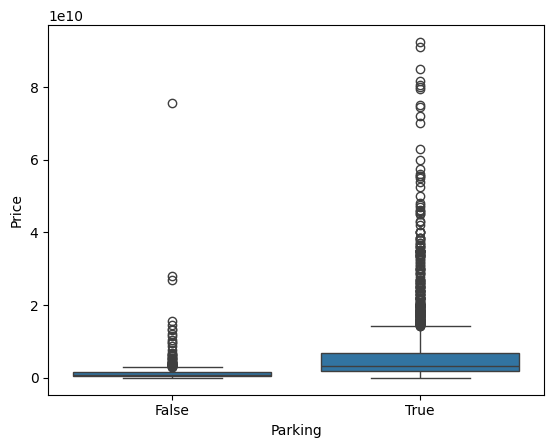

In [47]:
import seaborn as sns
sns.boxplot(data=df, x='Parking', y='Price')

In [48]:
nopark = df[df['Parking'] == False]
nopark.nlargest(10, 'Price')

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
3107,630,0,False,False,False,Tajrish,7.560000e+10,2520000.00,1.200000e+08
3193,320,5,False,False,False,Sattarkhan,2.800000e+10,933333.33,8.750000e+07
1349,300,3,False,False,False,Lavasan,2.700000e+10,900000.00,9.000000e+07
1463,170,3,False,False,False,Velenjak,1.570000e+10,523333.33,9.235294e+07
1996,170,3,False,False,False,Gheitarieh,1.450000e+10,483333.33,8.529412e+07
2016,202,3,False,False,False,Araj,1.350000e+10,450000.00,6.683168e+07
2006,202,3,False,False,False,Araj,1.330000e+10,443333.33,6.584158e+07
2111,200,5,False,False,False,Dehkade Olampic,1.200000e+10,400000.00,6.000000e+07
3130,171,2,False,True,False,Elahieh,1.150000e+10,383333.33,6.725146e+07
1092,150,3,False,False,False,Gheitarieh,1.050000e+10,350000.00,7.000000e+07


In [49]:
tajrish = df[df['Address'] == 'Tajrish']
tajrish

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
355,110,2,True,True,True,Tajrish,6.600000e+09,220000.00,6.000000e+07
1148,115,2,True,True,True,Tajrish,8.200000e+09,273333.33,7.130435e+07
2584,300,4,True,True,True,Tajrish,9.000000e+09,300000.00,3.000000e+07
2769,100,2,True,True,True,Tajrish,5.700000e+09,190000.00,5.700000e+07
2831,100,2,True,True,True,Tajrish,5.700000e+09,190000.00,5.700000e+07
3096,150,3,True,True,True,Tajrish,1.275000e+10,425000.00,8.500000e+07
3107,630,0,False,False,False,Tajrish,7.560000e+10,2520000.00,1.200000e+08


In [50]:
df = df.drop(3107)

In [51]:
len(df)

3447

In [52]:
sattar = df[df['Address'] == 'Sattarkhan']
sattar

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
75,114,3,True,True,True,Sattarkhan,5.500000e+09,183333.33,4.824561e+07
81,114,3,True,True,True,Sattarkhan,5.500000e+09,183333.33,4.824561e+07
401,82,2,True,True,True,Sattarkhan,4.100000e+09,136666.67,5.000000e+07
1585,84,2,False,True,False,Sattarkhan,2.600000e+09,86666.67,3.095238e+07
1688,97,2,True,True,True,Sattarkhan,3.580000e+09,119333.33,3.690722e+07
2153,118,3,True,True,True,Sattarkhan,4.900000e+09,163333.33,4.152542e+07
2155,124,3,True,True,True,Sattarkhan,3.400000e+09,113333.33,2.741935e+07
2190,78,2,True,True,False,Sattarkhan,2.100000e+09,70000.00,2.692308e+07
2199,78,2,True,True,False,Sattarkhan,2.010000e+09,67000.00,2.576923e+07
2414,102,2,True,True,True,Sattarkhan,6.500000e+08,21666.67,6.372549e+06


In [53]:
len(sattar)

12

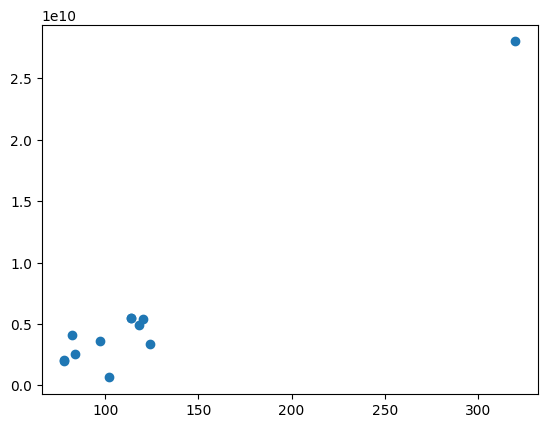

In [54]:
plt.scatter(sattar['Area'], sattar['Price'])
plt.show()

In [55]:
df = df.drop(3193)

In [56]:
lavasan = df[df['Address'] == 'Lavasan']
lavasan

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
430,400,5,True,True,False,Lavasan,8.500000e+10,2833333.33,2.125000e+08
431,660,5,True,True,False,Lavasan,5.500000e+10,1833333.33,8.333333e+07
1349,300,3,False,False,False,Lavasan,2.700000e+10,900000.00,9.000000e+07
2779,300,5,True,True,False,Lavasan,2.500000e+10,833333.33,8.333333e+07


In [57]:
df.nlargest(10, 'Price')

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
1707,420,4,True,True,True,Zaferanieh,9.240000e+10,3080000.00,2.200000e+08
1810,705,5,True,True,False,Abazar,9.100000e+10,3033333.33,1.290780e+08
430,400,5,True,True,False,Lavasan,8.500000e+10,2833333.33,2.125000e+08
819,680,5,True,True,False,Ekhtiarieh,8.160000e+10,2720000.00,1.200000e+08
1332,350,4,True,True,True,Niavaran,8.050000e+10,2683333.33,2.300000e+08
1694,929,5,True,True,False,Zafar,8.000000e+10,2666666.67,8.611410e+07
3051,530,4,True,True,True,Dorous,7.950000e+10,2650000.00,1.500000e+08
831,750,5,True,True,True,Mahmoudieh,7.500000e+10,2500000.00,1.000000e+08
2394,310,3,True,True,True,Aqdasieh,7.440000e+10,2480000.00,2.400000e+08
2194,350,4,True,True,True,Niavaran,7.200000e+10,2400000.00,2.057143e+08


In [58]:
df = df.drop(1810)

In [60]:
stats = df.groupby('Address')['Price Per Meter'].agg(['mean', 'count'])
stats.nlargest(10, 'mean')

,mean,count
Address,,
Gandhi,1.400000e+08,1
Vanak,1.274156e+08,2
Lavasan,1.172917e+08,4
Zaferanieh,1.137139e+08,27
Elahieh,1.122126e+08,17
Velenjak,1.116799e+08,22
Kamranieh,1.036243e+08,14
Niavaran,1.027806e+08,68
Farmanieh,1.023298e+08,57


In [61]:
stats.loc['Amir Bahador']

mean     6.098246e+07
count    4.000000e+00
Name: Amir Bahador, dtype: float64

<Axes: xlabel='Elevator', ylabel='Price'>

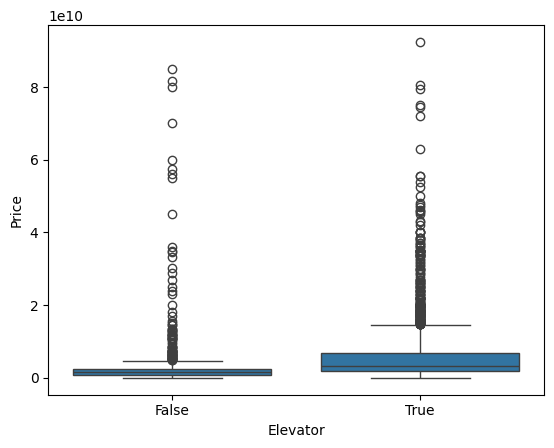

In [62]:
sns.boxplot(data=df, x='Elevator', y='Price')

In [64]:
elev = df[df['Elevator'] == False]
elev.nlargest(10, "Price Per Meter")

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
430,400,5,True,True,False,Lavasan,8.500000e+10,2833333.33,2.125000e+08
1635,287,5,True,True,False,Vanak,5.750000e+10,1916666.67,2.003484e+08
879,250,3,True,True,False,Niavaran,4.500000e+10,1500000.00,1.800000e+08
3031,57,1,False,True,False,Amir Bahador,9.800000e+09,326666.67,1.719298e+08
2960,212,4,True,True,False,Farmanieh,3.600000e+10,1200000.00,1.698113e+08
2598,180,5,True,True,False,Shahrake Gharb,2.880000e+10,960000.00,1.600000e+08
3254,240,3,True,True,False,Elahieh,3.456000e+10,1152000.00,1.440000e+08
1119,250,4,True,True,False,Shahrake Gharb,3.500000e+10,1166666.67,1.400000e+08
1270,400,5,True,True,False,Mirdamad,5.600000e+10,1866666.67,1.400000e+08
2706,500,5,True,True,False,Gandhi,7.000000e+10,2333333.33,1.400000e+08


In [65]:
molavi = df[df['Address'] == 'Amir Bahador']
molavi.value_counts()

Area  Room  Parking  Warehouse  Elevator  Address       Price         Price(USD)  Price Per Meter
57    1     False    True       False     Amir Bahador  9.800000e+09  326666.67   1.719298e+08       1
63    2     True     True       True      Amir Bahador  1.638000e+09  54600.00    2.600000e+07       1
74    2     True     True       True      Amir Bahador  1.702000e+09  56733.33    2.300000e+07       1
93    2     True     True       True      Amir Bahador  2.139000e+09  71300.00    2.300000e+07       1
Name: count, dtype: int64

In [66]:
df = df.drop(3031)

<Axes: xlabel='Warehouse', ylabel='Price'>

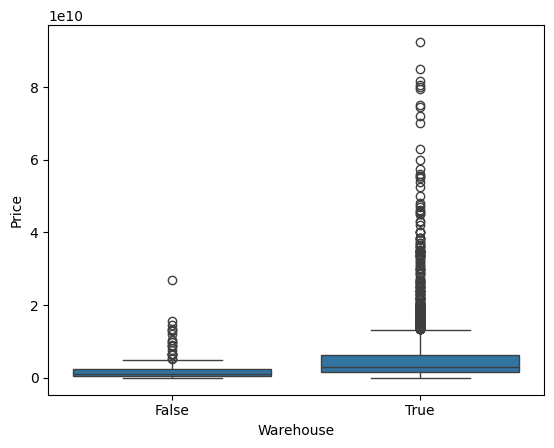

In [67]:
sns.boxplot(data=df, x='Warehouse', y='Price')

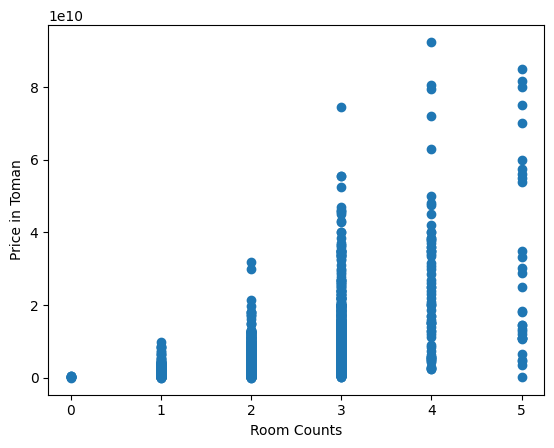

In [68]:
plt.scatter(df['Room'], df['Price'])
plt.xlabel("Room Counts")
plt.ylabel("Price in Toman")
plt.show()

In [69]:
zero = df[df["Room"] == 0]

In [70]:
zero

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price Per Meter
103,40,0,False,False,False,Shahrake Qods,248000000.0,8266.67,6.200000e+06
137,40,0,False,False,False,Pakdasht,165000000.0,5500.00,4.125000e+06
1169,40,0,False,True,False,Ostad Moein,650000000.0,21666.67,1.625000e+07
2084,40,0,False,False,False,Pakdasht,165000000.0,5500.00,4.125000e+06
2103,43,0,False,True,False,Nasim Shahr,360000000.0,12000.00,8.372093e+06
2625,50,0,True,True,True,Northern Chitgar,345000000.0,11500.00,6.900000e+06
2721,110,0,True,True,True,Parand,102000000.0,3400.00,9.272727e+05
3211,30,0,False,True,False,Ostad Moein,500000000.0,16666.67,1.666667e+07
3435,54,0,False,False,False,Shahrake Qods,470000000.0,15666.67,8.703704e+06


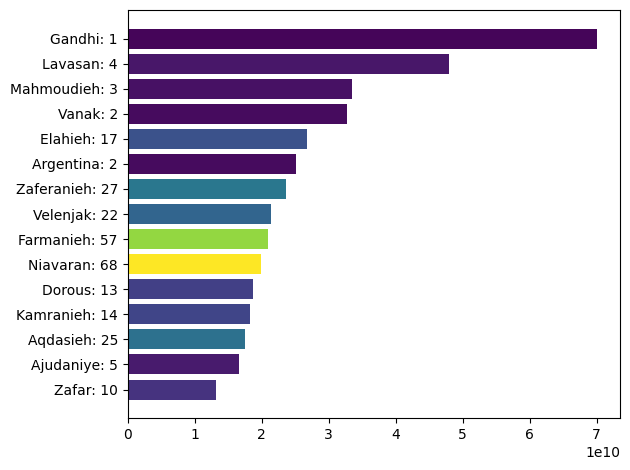

In [73]:
neigh = df.groupby("Address")['Price'].agg(['mean','count']).nlargest(15, 'mean').sort_values('mean')
labels = neigh.index + ': ' + neigh['count'].astype(str)
plt.barh(labels, neigh['mean'], color=plt.cm.viridis(neigh['count']/neigh['count'].max()))
plt.tight_layout()
plt.show()

In [91]:
counts = df["Address"].value_counts()
rare = counts[counts<5].index
df['Address'] = df['Address'].replace(rare, 'Other')

df = pd.get_dummies(df, columns=['Address'], drop_first=True, dtype=int)

In [75]:
len(rare)

94

In [76]:
len(counts)

192

In [77]:
rare.sum()

182

In [92]:
df.head()

,Area,Room,Parking,Warehouse,Elevator,Price,Price(USD),Price Per Meter,Address_Absard,Address_Afsarieh,...,Address_Tarasht,Address_Tehransar,Address_Tenant,Address_Valiasr,Address_Velenjak,Address_West Ferdows Boulevard,Address_West Pars,Address_Yousef Abad,Address_Zafar,Address_Zaferanieh
0,63,1,True,True,True,1.850000e+09,61666.67,2.936508e+07,0,0,...,0,0,0,0,0,0,0,0,0,0
1,60,1,True,True,True,1.850000e+09,61666.67,3.083333e+07,0,0,...,0,0,0,0,0,0,0,0,0,0
2,79,2,True,True,True,5.500000e+08,18333.33,6.962025e+06,0,0,...,0,0,0,0,0,0,0,0,0,0
3,95,2,True,True,True,9.025000e+08,30083.33,9.500000e+06,0,0,...,0,0,0,0,0,0,0,0,0,0
4,123,2,True,True,True,7.000000e+09,233333.33,5.691057e+07,0,0,...,0,0,0,0,0,0,0,0,0,0


In [98]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_squared_error

x = df.drop(columns = ['Price', 'Price Per Meter', 'Price(USD)'])
y = df['Price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

model = LinearRegression()
model.fit(x_train, y_train)

pred = model.predict(x_test)
print(mean_absolute_error(y_test, pred))
print(r2_score(y_test, pred))
print(root_mean_squared_error(y_test, pred))

2115823315.7376955
0.7573358841580651
4501578365.181624


In [ ]:
model.predict([])

In [ ]:
df.head([])

,Area,Room,Parking,Warehouse,Elevator,Price,Price(USD),Price Per Meter,Address_Absard,Address_Afsarieh,...,Address_Tarasht,Address_Tehransar,Address_Tenant,Address_Valiasr,Address_Velenjak,Address_West Ferdows Boulevard,Address_West Pars,Address_Yousef Abad,Address_Zafar,Address_Zaferanieh
0,63,1,True,True,True,1.850000e+09,61666.67,2.936508e+07,0,0,...,0,0,0,0,0,0,0,0,0,0
1,60,1,True,True,True,1.850000e+09,61666.67,3.083333e+07,0,0,...,0,0,0,0,0,0,0,0,0,0
2,79,2,True,True,True,5.500000e+08,18333.33,6.962025e+06,0,0,...,0,0,0,0,0,0,0,0,0,0
3,95,2,True,True,True,9.025000e+08,30083.33,9.500000e+06,0,0,...,0,0,0,0,0,0,0,0,0,0
4,123,2,True,True,True,7.000000e+09,233333.33,5.691057e+07,0,0,...,0,0,0,0,0,0,0,0,0,0


In [109]:
test = pd.DataFrame(0, index=[0], columns=x_train.columns)
test['Area'] = 150
test['Room'] = 3
test['Parking'] = 1
test['Warehouse'] = 1
test['Elevator'] = 1
test['Address_Elahieh'] = 1

In [110]:
test

,Area,Room,Parking,Warehouse,Elevator,Address_Absard,Address_Afsarieh,Address_Air force,Address_Ajudaniye,Address_Amirabad,...,Address_Tarasht,Address_Tehransar,Address_Tenant,Address_Valiasr,Address_Velenjak,Address_West Ferdows Boulevard,Address_West Pars,Address_Yousef Abad,Address_Zafar,Address_Zaferanieh
0,150,3,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [112]:
model.predict(test)[0]

22645062526.656807